In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Thiết lập style cơ bản cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu
df = pd.read_csv('../data/vietnam_housing_dataset.csv') # Đổi lại tên file cho khớp với file của bạn

# 2. Xem 5 dòng đầu tiên để có cái nhìn trực quan
display(df.head())

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## Ta tiến hành xử lý các cột bị thiếu thông tin

In [62]:
# 1. Xóa các cột có quá nhiều dữ liệu thiếu (chọn lọc các cột không cần thiết)
cols_to_drop = ['Balcony direction', 'House direction', 'Furniture state', 'Access Road', 'Frontage']

df_cleaned = df.drop(columns=cols_to_drop)

# 2. Điền khuyết cho các cột số học (dùng Median)
numeric_cols = ['Floors', 'Bedrooms', 'Bathrooms']
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# 3. Điền khuyết cột phân loại (Gán 'Sale contract' vì thiếu thông tin thường là giấy tay/chưa sổ)
df_cleaned['Legal status'] = df_cleaned['Legal status'].fillna('Sale contract')


print("Số lượng dữ liệu thiếu hiện tại:")
display(df_cleaned.isnull().sum())

print("\n5 dòng dữ liệu đầu tiên sau khi xử lý:")
display(df_cleaned.head())

Số lượng dữ liệu thiếu hiện tại:


Address         0
Area            0
Floors          0
Bedrooms        0
Bathrooms       0
Legal status    0
Price           0
dtype: int64


5 dòng dữ liệu đầu tiên sau khi xử lý:


,Address,Area,Floors,Bedrooms,Bathrooms,Legal status,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,4.0,3.0,3.0,Have certificate,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,5.0,3.0,3.0,Sale contract,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,5.0,3.0,3.0,Sale contract,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,2.0,2.0,3.0,Have certificate,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,2.0,4.0,4.0,Have certificate,6.90


1. Xóa cột (Drop Columns) - Dành cho tỷ lệ thiếu > 50%
Ngoài các cột Address, Area và Price ra, các cột khác đều có những khoảng bị thiếu dữ liệu, Balcony direction (thiếu 24.983) và House direction (thiếu 21.239). Số lượng khuyết quá lớn, nếu cố tình điền bừa sẽ làm sai lệch mô hình. Các cột như Access Road (13.297) hay Furniture state (14.119) cũng nên được cân nhắc.

2. Điền khuyết (Imputation) - Dành cho dữ liệu thiếu < 20-30%
Các cột như Floors (3603), Bedrooms (5162), Bathrooms (7074) là những đặc trưng cực kỳ quan trọng quyết định giá nhà. Thay vì xóa cột hay xóa dòng (gây lãng phí dữ liệu), chúng ta sẽ điền vào chỗ trống. Ví dụ, số lượng (phòng, tầng): Điền trung vị (median). (Ví dụ: Đa số nhà có 2 phòng ngủ, ta điền số 2 vào các ô bị trống). Còn đối với Legal status, các giá trị trống sẽ được thay bằng 'Sale contract' vì với các bất động sản bị bỏ trống thông tin thường có nguy cơ là do buôn bán sang tay.

3. Xóa dòng (Drop Rows) - Dành cho tỷ lệ thiếu rất nhỏ
Nếu sau khi xử lý mà vẫn còn rải rác vài chục hoặc vài trăm dòng bị thiếu thông tin ở một số cột, bạn có thể dùng lệnh df.dropna() để xóa các dòng đó đi. Với một dataset hàng chục ngàn dòng, việc mất đi một lượng nhỏ không đáng kể.

## Feature engineering

In [63]:
# 1. Tách thông tin địa lý từ Address
df_cleaned['City'] = df_cleaned['Address'].apply(lambda x: str(x).split(',')[-1].strip())
df_cleaned['District'] = df_cleaned['Address'].apply(
    lambda x: str(x).split(',')[-2].strip() if len(str(x).split(',')) > 1 else None
)

# Kiểm tra xem có bao nhiêu giá trị City/District khác nhau
print("Số lượng City khác nhau:", df_cleaned['City'].nunique())
print(df_cleaned['City'].value_counts())
print("\nSố lượng District khác nhau:", df_cleaned['District'].nunique())
print(df_cleaned['District'].value_counts())

Số lượng City khác nhau: 107
City
Hồ Chí Minh                            11628
Hà Nội                                  9996
Bình Dương                              1655
Đà Nẵng                                 1411
Đồng Nai                                 806
                                       ...  
Quận 8                                     1
Kon Tum.                                   1
TP Hồ Chí Minh                             1
TP. Cam Ranh                               1
Quảng Ninh (Ngã 3 đường Hòn Gai cũ)        1
Name: count, Length: 107, dtype: int64

Số lượng District khác nhau: 341
District
Gò Vấp          1373
Hà Đông         1285
Long Biên       1242
Bình Tân        1159
Thủ Đức         1145
                ... 
Tân Thạnh          1
Thuận Nam          1
Tịnh Biên          1
Quận Ba Đình       1
Ea Kar             1
Name: count, Length: 341, dtype: int64


Có thể thấy, định dạng của phần địa chỉ không thực sự chuẩn xác 100% mà nó có bao gồm các lỗi đánh máy, định dạng số lượng dấu phẩy, dấu chấm khác nhau, cho nên ta cần xử lý để có thể tách Thành Phố và Quận Huyện chính xác hơn.

In [64]:
# ============================================
# Chuẩn hóa cột City
# ============================================
def clean_city(x):
    x = str(x).strip()
    # Bỏ các tiền tố dạng "TP.", "TP ", "Tp.", "Thành phố"
    x = re.sub(r'^(TP\.?\s*|Tp\.?\s*|Thành phố\s*)', '', x)
    # Bỏ phần trong dấu ngoặc (VD: "Quảng Ninh (Ngã 3...)")
    x = re.sub(r'\(.*?\)', '', x).strip()
    # Bỏ dấu chấm cuối câu
    x = x.rstrip('.')
    return x.title()

df_cleaned['City'] = df_cleaned['City'].apply(clean_city)

print("Số lượng City sau chuẩn hóa:", df_cleaned['City'].nunique())
print(df_cleaned['City'].value_counts().head(20))

Số lượng City sau chuẩn hóa: 73
City
Hồ Chí Minh        11779
Hà Nội             10457
Bình Dương          1673
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Lâm Đồng             118
Quảng Ninh           111
Cần Thơ              111
Thanh Hóa            109
Kiên Giang            83
Đắk Lắk               77
Hà Nam                49
Bình Định             48
Name: count, dtype: int64


In [65]:
# Gộp các City ít xuất hiện vào "Other"
city_counts = df_cleaned['City'].value_counts()
top_cities = city_counts[city_counts >= 50].index  # ngưỡng: xuất hiện >= 50 lần
df_cleaned['City'] = df_cleaned['City'].apply(lambda x: x if x in top_cities else 'Other')

print("Số lượng City sau khi gộp:", df_cleaned['City'].nunique())
print(df_cleaned['City'].value_counts())

Số lượng City sau khi gộp: 19
City
Hồ Chí Minh        11779
Hà Nội             10457
Bình Dương          1673
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Other                635
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Lâm Đồng             118
Quảng Ninh           111
Cần Thơ              111
Thanh Hóa            109
Kiên Giang            83
Đắk Lắk               77
Name: count, dtype: int64


Sau quá trình xem xét sơ bộ, nhận thấy cột District có quá nhiều giá trị và có thể gây nhiễu cho mô hình, bên cạnh đó, dự án này là một dự án luyện tập ưu tiên sự đơn giản hơn cho nên tôi sẽ bỏ qua cột District và chỉ tập trung vào City.

In [66]:
df_cleaned = df_cleaned.drop(columns=['District'], errors='ignore')
print(df_cleaned.head(10))

                                             Address  Area  Floors  Bedrooms  \
0  Dự án The Empire - Vinhomes Ocean Park 2, Xã L...  84.0     4.0       3.0   
1  Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...  60.0     5.0       3.0   
2  Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...  90.0     5.0       3.0   
3  Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...  54.0     2.0       2.0   
4   Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh  92.0     2.0       4.0   
5  Dự án The Empire - Vinhomes Ocean Park 2, Xã L...  91.0     3.0       3.0   
6  Dự án The Empire - Vinhomes Ocean Park 2, Xã L...  64.0     5.0       3.0   
7  Dự án Him Lam Thường Tín, Huyện Thường Tín, Hà...  74.0     5.0       4.0   
8  Dự án The Empire - Vinhomes Ocean Park 2, Xã L...  48.0     5.0       6.0   
9  Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...  91.0     5.0       3.0   

   Bathrooms      Legal status  Price         City  
0        3.0  Have certificate   8.60     Hưng Yên  
1        3.0 

#Kiểm tra outlier

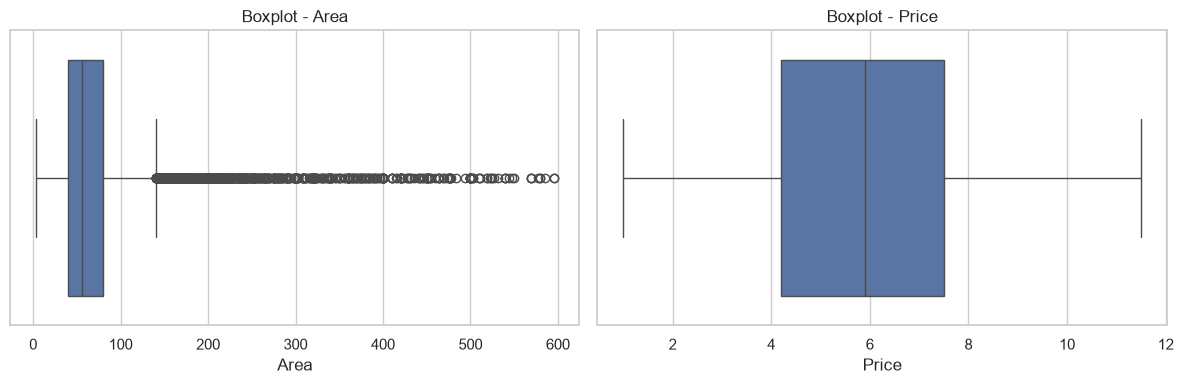

count    30229.000000
mean        68.498741
std         48.069835
min          3.100000
25%         40.000000
50%         56.000000
75%         80.000000
max        595.000000
Name: Area, dtype: float64
count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_cleaned['Area'], ax=axes[0])
axes[0].set_title('Boxplot - Area')
sns.boxplot(x=df_cleaned['Price'], ax=axes[1])
axes[1].set_title('Boxplot - Price')
plt.tight_layout()
plt.show()

print(df_cleaned['Area'].describe())
print(df_cleaned['Price'].describe())

Đối với Diện tích (Area): Dữ liệu bị lệch rất nặng. Hộp màu xanh bị ép chặt về bên trái, cho thấy đại đa số các căn nhà chỉ dao động trong khoảng hẹp (từ tầm 40m² đến 80m²). Tuy nhiên, có một "đám mây" chấm tròn kéo dài tít tắp đến tận 600m². Đây là những căn biệt thự hoặc lô đất khổng lồ.

Đối với Giá nhà (Price): Biểu đồ này lại rất đẹp. Hộp xanh nằm cân đối, hai râu kéo dài và không có bất kỳ chấm tròn nào. Điều này chứng tỏ dữ liệu giá của bạn phân bố khá đồng đều từ hơn 1 tỷ đến gần 12 tỷ, không có căn nhà nào có giá "trên trời" (kiểu 100 - 200 tỷ) lọt vào làm nhiễu.

In [68]:
# Tính ngưỡng outlier bằng IQR
Q1 = df_cleaned['Area'].quantile(0.25)
Q3 = df_cleaned['Area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Ngưỡng lọc Area: {lower_bound:.1f} - {upper_bound:.1f}")

df_cleaned = df_cleaned[(df_cleaned['Area'] >= max(lower_bound, 10)) & 
                         (df_cleaned['Area'] <= upper_bound)]

print("Số dòng còn lại sau lọc outlier:", df_cleaned.shape[0])

Ngưỡng lọc Area: -20.0 - 140.0
Số dòng còn lại sau lọc outlier: 28587


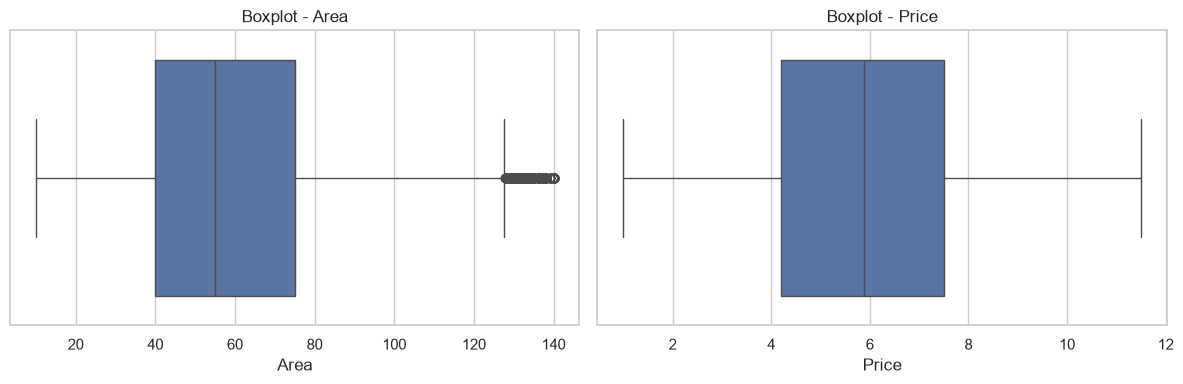

count    28587.000000
mean        60.015463
std         25.684588
min         10.000000
25%         40.000000
50%         55.000000
75%         75.000000
max        140.000000
Name: Area, dtype: float64
count    28587.000000
mean         5.861307
std          2.191660
min          1.000000
25%          4.200000
50%          5.880000
75%          7.500000
max         11.500000
Name: Price, dtype: float64


In [69]:
#Ta xem lại kết quả
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_cleaned['Area'], ax=axes[0])
axes[0].set_title('Boxplot - Area')
sns.boxplot(x=df_cleaned['Price'], ax=axes[1])
axes[1].set_title('Boxplot - Price')
plt.tight_layout()
plt.show()

print(df_cleaned['Area'].describe())
print(df_cleaned['Price'].describe())

Drop cột Address (không cần nữa vì đã tách City)

In [70]:
df_cleaned = df_cleaned.drop(columns=['Address'])

#One-hot encoding

In [71]:
df_encoded = pd.get_dummies(
    df_cleaned, 
    columns=['Legal status', 'City'], 
    drop_first=True
)

print("Shape sau khi encode:", df_encoded.shape)
display(df_encoded.head())

Shape sau khi encode: (28587, 24)


,Area,Floors,Bedrooms,Bathrooms,Price,Legal status_Sale contract,City_Bình Dương,City_Bình Thuận,City_Bắc Ninh,City_Cần Thơ,...,City_Khánh Hòa,City_Kiên Giang,City_Long An,City_Lâm Đồng,City_Other,City_Quảng Ninh,City_Thanh Hóa,City_Đà Nẵng,City_Đắk Lắk,City_Đồng Nai
0,84.0,4.0,3.0,3.0,8.60,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60.0,5.0,3.0,3.0,7.50,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,90.0,5.0,3.0,3.0,8.90,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,54.0,2.0,2.0,3.0,5.35,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,92.0,2.0,4.0,4.0,6.90,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


 #Correlation heatmap với Price

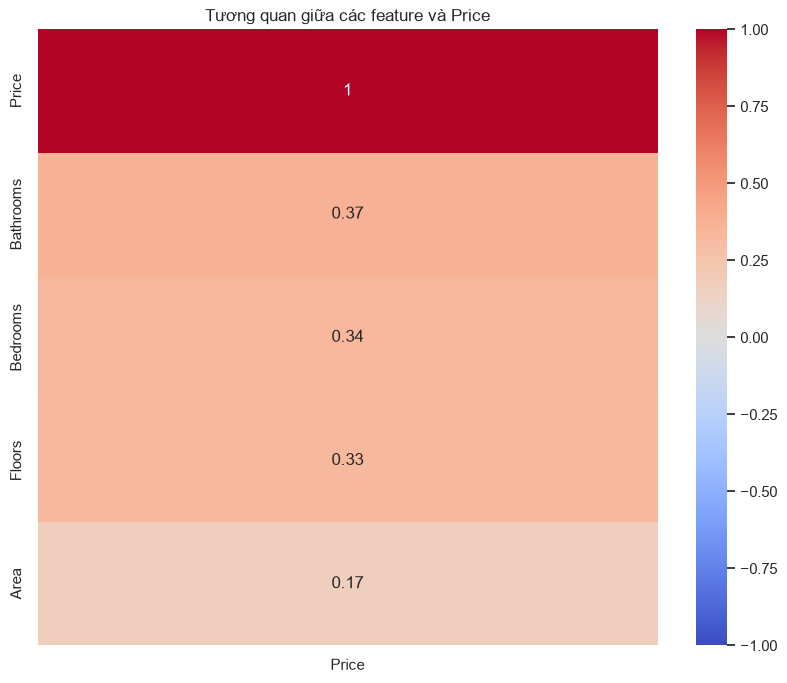

In [72]:
plt.figure(figsize=(10, 8))
corr = df_encoded.select_dtypes(include='number').corr()
sns.heatmap(corr[['Price']].sort_values(by='Price', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Tương quan giữa các feature và Price')
plt.show()

Bathrooms (0.37) và Bedrooms (0.34): Đây là hai yếu tố có tương quan thuận mạnh nhất với giá nhà trong tập dữ liệu. Nhà càng nhiều phòng ngủ/phòng tắm thì quy mô và tiện ích càng cao, dẫn đến giá trị lớn hơn.

Floors (0.33): Số tầng cũng đóng vai trò quan trọng không kém, tương đương với số phòng ngủ.

Area (0.17): Đây là một kết quả cực kỳ thú vị và đáng ngạc nhiên. Thông thường, diện tích phải là yếu tố quyết định giá nhà hàng đầu. Tuy nhiên, hệ số 0.17 cho thấy mối tương quan khá yếu. Tại sao lại như vậy?

Nguyên nhân 1 (Tính phi tuyến): Có thể mối quan hệ giữa Area và Price không phải là đường thẳng.

Nguyên nhân 2 (Ảnh hưởng của Vị trí): Một căn nhà 30m² ở Quận 1 (TP.HCM) có thể đắt hơn căn 100m² ở ngoại thành. Vì chúng ta chưa xem xét yếu tố Vị trí trong biểu đồ này, nên chỉ riêng diện tích chưa đủ để giải thích sự chênh lệch giá.

##Lựa chọn features
Area, Floors, Bedrooms, Bathrooms là các đặc điểm vật lý cơ bản của nhà — về mặt domain knowledge, tất cả đều có lý do chính đáng để ảnh hưởng đến giá. Legal status và City bổ sung yếu tố pháp lý và vị trí.
Nên đây sẽ được giữ lại làm features để train model.

#Lưu file đã xử lý

In [73]:
df_encoded.to_csv('../data/processed_data.csv', index=False)
print("Đã lưu file processed_data.csv, shape:", df_encoded.shape)

Đã lưu file processed_data.csv, shape: (28587, 24)
